<div style="background-color: RGB(0,114,200);">
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 11 — DATA ANALYST</h1>
<h2 style="margin: auto; padding: 10px 0; color:#fff; text-align: center">Produisez une étude de marché avec Python</h2>
</div>


## Sommaire

1. [Import des librairies](#import)
2. [Importation et exploration des données](#exploration)
    - 2.1 [Structure et statistiques descriptives](#structure)
    - 2.2 [Détection des outliers](#outliers)
    - 2.3 [Matrice de corrélation](#correlation)
3. [Analyse en Composantes Principales (ACP)](#acp)
    - 3.1 [Standardisation des données](#standardisation)
    - 3.2 [Calcul de l'ACP et éboulis des valeurs propres](#eboulis)
    - 3.3 [Cercle des corrélations](#cercle)
    - 3.4 [Projection des individus](#projection)
4. [Clustering](#clustering)
    - 4.1 [CAH et dendrogramme](#cah)
    - 4.2 [KMeans et méthode du coude](#kmeans)
    - 4.3 [Application du KMeans (k=4)](#application)
    - 4.4 [Comparaison CAH et KMeans](#comparaison)
    - 4.5 [Recommandations pour l'entreprise](#recommandations)


<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="import"><h2 style="margin: auto; padding: 20px; color:#fff;">1. Import des librairies</h2></a>
</div>


In [1]:
#Importation des librairies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
from matplotlib.collections import LineCollection
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="exploration"><h2 style="margin: auto; padding: 20px; color:#fff;">2. Importation et exploration des données</h2></a>
</div>


In [2]:
# On charge le fichier CSV dans un DataFrame nommé "df"
df = pd.read_csv("donnees_pretes.csv")

# On regarde les 5 premières lignes pour vérifier que tout est bien chargé
df.head()

,Zone,Population_2017,Croissance_demo,Proteines_totales,Kcal_totales,Volaille_kg_hab,Taux_dependance_import,Ratio_proteines_animales,Code zone,ISO3,PIB_par_hab_2017,Stabilite_politique_2017
0,Afghanistan,36296.113,74.668889,54.09,1997.0,1.53,0.300879,0.195045,2,AFG,525.469771,-2.613931
1,Afrique du Sud,57009.756,26.779324,83.36,2987.0,35.69,0.134949,0.408709,202,ZAF,6618.335083,-0.382832
2,Albanie,2884.169,-7.831734,119.50,3400.0,16.36,0.181185,0.552050,3,ALB,5006.360130,0.163830
3,Algérie,41389.189,33.331859,92.85,3345.0,6.38,0.434652,0.275821,4,DZA,4554.667540,-0.929505
4,Allemagne,82658.409,1.544857,104.07,3559.0,19.47,0.380373,0.588354,79,DEU,45553.934150,0.702224


<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="structure"><h2 style="margin: auto; padding: 20px; color:#fff;">2.1 Structure et statistiques descriptives</h2></a>
</div>


In [3]:
#Affichage des informations sur le DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Zone                      165 non-null    object 
 1   Population_2017           165 non-null    float64
 2   Croissance_demo           165 non-null    float64
 3   Proteines_totales         165 non-null    float64
 4   Kcal_totales              165 non-null    float64
 5   Volaille_kg_hab           165 non-null    float64
 6   Taux_dependance_import    165 non-null    float64
 7   Ratio_proteines_animales  165 non-null    float64
 8   Code zone                 165 non-null    int64  
 9   ISO3                      165 non-null    object 
 10  PIB_par_hab_2017          165 non-null    float64
 11  Stabilite_politique_2017  165 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 15.6+ KB


In [4]:
#Afficher les statistiques descriptives du DataFrame
df.describe()

,Population_2017,Croissance_demo,Proteines_totales,Kcal_totales,Volaille_kg_hab,Taux_dependance_import,Ratio_proteines_animales,Code zone,PIB_par_hab_2017,Stabilite_politique_2017
count,1.650000e+02,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,4.405366e+04,29.702823,81.109939,2862.181818,20.170061,0.327993,0.414353,123.684848,14204.770631,-0.074190
std,1.561502e+05,29.061688,20.278883,455.639704,15.802588,0.295817,0.155261,71.256990,19487.701693,0.862398
min,5.204500e+01,-18.745151,39.910000,1754.000000,0.130000,0.005682,0.088970,1.000000,432.324026,-2.730503
25%,2.920848e+03,9.302260,64.040000,2515.000000,6.460000,0.108542,0.275834,63.000000,2012.286626,-0.653347
50%,9.785843e+03,25.088601,81.150000,2872.000000,18.200000,0.219358,0.426698,120.000000,5955.297386,-0.028302
75%,3.110465e+04,46.437500,96.270000,3251.000000,29.330000,0.471465,0.547015,184.000000,17566.099970,0.673810
max,1.421022e+06,202.712678,141.340000,3770.000000,72.310000,1.520410,0.720627,256.000000,110193.213797,1.492485


<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="outliers"><h2 style="margin: auto; padding: 20px; color:#fff;">2.2 Détection des outliers</h2></a>
</div>


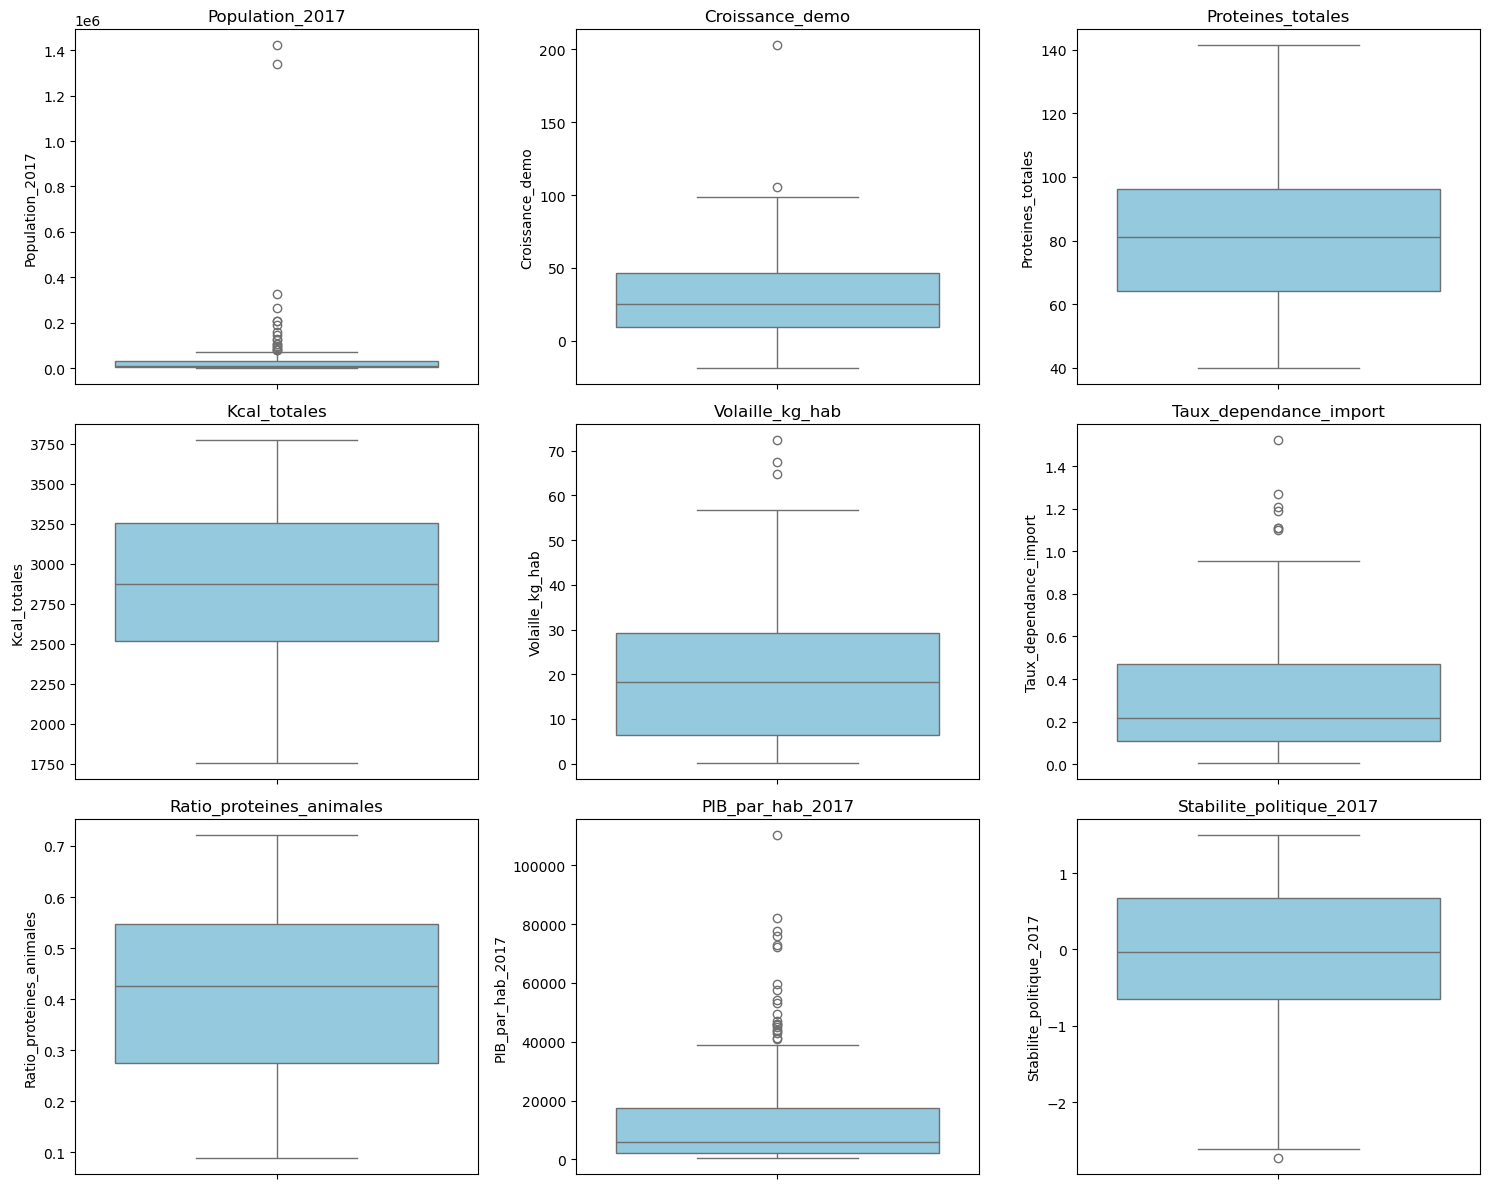

In [5]:
# On définit la liste des 9 variables d'analyse
vars_analyse = ['Population_2017', 'Croissance_demo', 'Proteines_totales',
                'Kcal_totales', 'Volaille_kg_hab', 'Taux_dependance_import',
                'Ratio_proteines_animales', 'PIB_par_hab_2017', 'Stabilite_politique_2017']

# On crée une figure avec une grille de 3 lignes x 3 colonnes = 9 cases
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# "axes" est une grille 3x3 ; .flatten() la transforme en une simple liste de 9 cases
# pour pouvoir les parcourir une par une avec une boucle
axes = axes.flatten()

# On parcourt les 9 variables : "i" est la position (0,1,2...), "col" est le nom de la variable
for i, col in enumerate(vars_analyse):
    # On dessine le boxplot de la variable "col" dans la case numéro i
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    # On met le nom de la variable comme titre de la case
    axes[i].set_title(col)

# Ajuste automatiquement les espaces pour que les titres ne se chevauchent pas
plt.tight_layout()

# Affiche la figure à l'écran
plt.show()

In [6]:
# On parcourt une par une les 9 variables d'analyse
for col in vars_analyse:

    # Q1 = 1er quartile : la valeur en dessous de laquelle se trouvent 25% des pays
    Q1 = df[col].quantile(0.25)

    # Q3 = 3e quartile : la valeur en dessous de laquelle se trouvent 75% des pays
    Q3 = df[col].quantile(0.75)

    # IQR = écart interquartile = largeur de la boîte du boxplot
    IQR = Q3 - Q1

    # Borne basse : en dessous, un pays est considéré comme outlier
    borne_basse = Q1 - 1.5 * IQR

    # Borne haute : au-dessus, un pays est considéré comme outlier
    borne_haute = Q3 + 1.5 * IQR

    # On sélectionne les pays dont la valeur sort des bornes
    outliers = df[(df[col] < borne_basse) | (df[col] > borne_haute)]

    # On affiche le nom de la variable et le nombre d'outliers trouvés
    print(f"\n=== {col} : {len(outliers)} outlier(s) ===")

    # S'il y a au moins un outlier, on affiche les pays concernés et leur valeur
    if len(outliers) > 0:
        # On affiche seulement la colonne du pays (Zone) et la variable concernée,
        # triées par valeur croissante, sans afficher le numéro d'index
        print(outliers[['Zone', col]].sort_values(by=col).to_string(index=False))


=== Population_2017 : 18 outlier(s) ===
                          Zone  Population_2017
Iran (République islamique d')        80673.883
                       Turquie        81116.450
                     Allemagne        82658.409
                      Viet Nam        94600.648
                        Égypte        96442.591
                   Philippines       105172.925
                      Éthiopie       106399.924
                       Mexique       124777.324
                         Japon       127502.725
          Fédération de Russie       145530.082
                    Bangladesh       159685.424
                       Nigéria       190873.244
                        Brésil       207833.823
                      Pakistan       207906.209
                     Indonésie       264650.963
         États-Unis d'Amérique       325084.756
                          Inde      1338676.785
           Chine, continentale      1421021.791

=== Croissance_demo : 2 outlier(s) ===
       

## Analyse des distributions et des outliers

La détection par la méthode IQR (écart interquartile) donne les résultats suivants :

- **Population_2017 (18 outliers)** : les pays les plus peuplés (Chine et Inde > 1 milliard, 
puis États-Unis, Indonésie, Pakistan, Brésil...). Géants démographiques réels.
- **Croissance_demo (2)** : Oman (+106 %) et Émirats arabes unis (+203 %), du fait d'une forte 
immigration de main-d'œuvre entre 2000 et 2017.
- **Volaille_kg_hab (3)** : Samoa, Israël et Saint-Vincent-et-les-Grenadines, gros consommateurs 
de volaille par habitant.
- **Taux_dependance_import (7)** : Macao, Hong-Kong, Luxembourg, Djibouti, Pays-Bas, Belgique, 
Émirats — de petits territoires important plus qu'ils ne produisent (taux > 1).
- **PIB_par_hab_2017 (21)** : les pays les plus riches (Luxembourg, Suisse, Norvège, Irlande...).
- **Stabilite_politique_2017 (1)** : le Yémen (-2,73), en conflit en 2017.
- **Proteines_totales, Kcal_totales, Ratio_proteines_animales** : aucune valeur aberrante.

**Décision méthodologique :** tous ces outliers correspondent à des réalités et non à des erreurs 
de saisie. Ils sont donc **conservés**, car ils portent une information métier importante (grands 
marchés, pays riches, gros consommateurs de volaille). Leur présence, ainsi que les écarts 
d'échelle très marqués entre les variables, confirment la nécessité de **standardiser les données** 
(centrage-réduction) avant l'ACP, afin qu'aucune variable ne domine mécaniquement l'analyse.

<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="correlation"><h2 style="margin: auto; padding: 20px; color:#fff;">2.3 Matrice de corrélation</h2></a>
</div>


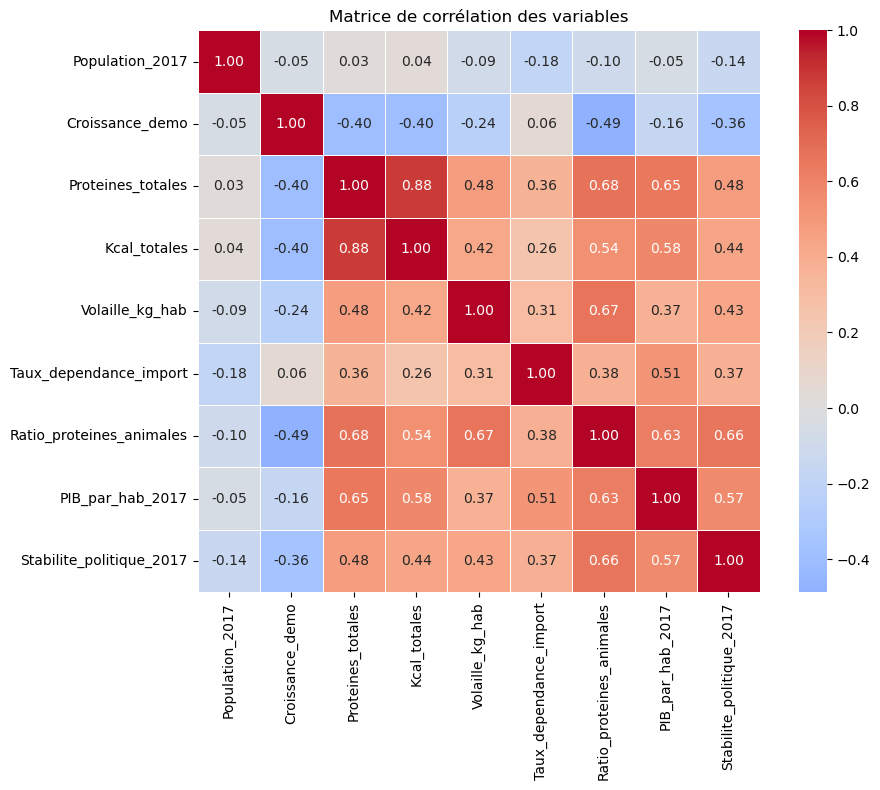

In [7]:
# On calcule la matrice de corrélation sur les 9 variables d'analyse
matrice_corr = df[vars_analyse].corr()

# On crée une figure de taille 10x8 pouces
plt.figure(figsize=(10, 8))

# On dessine la heatmap de la matrice de corrélation
sns.heatmap(
    matrice_corr,        # les données à afficher : notre matrice de corrélation
    annot=True,          # affiche la valeur chiffrée dans chaque case
    fmt=".2f",           # format des nombres : 2 chiffres après la virgule
    cmap="coolwarm",     # palette de couleurs : bleu = négatif, rouge = positif
    center=0,            # la couleur neutre (blanc) correspond à une corrélation de 0
    square=True,         # rend les cases carrées
    linewidths=0.5       # épaisseur des traits qui séparent les cases
)

# On ajoute un titre au graphique
plt.title("Matrice de corrélation des variables")

# Ajuste les espacements pour que tout soit lisible
plt.tight_layout()

# Affiche le graphique
plt.show()

## Analyse des corrélations

La matrice de corrélation met en évidence plusieurs liens forts entre les variables :

- **Proteines_totales et Kcal_totales** sont très fortement corrélées (0,88) : elles mesurent 
des aspects proches de la disponibilité alimentaire.
- Un ensemble de variables liées au **niveau de développement** se corrèlent entre elles : 
protéines totales, ratio de protéines animales, PIB par habitant, stabilité politique et 
consommation de volaille (corrélations de 0,5 à 0,7). Les pays riches, stables et gros 
consommateurs de protéines animales forment un groupe cohérent.
- **Croissance_demo** est corrélée négativement avec ces variables (jusqu'à -0,49) : les pays à 
forte croissance démographique consomment plutôt moins de protéines animales.
- **Population_2017** est quasiment indépendante des autres variables : la taille d'un pays 
n'est pas liée à sa richesse ni à son alimentation. Elle apporte une information propre.

Ces corrélations justifient le recours à l'ACP : plusieurs variables portent une information 
redondante, que l'ACP va synthétiser en un petit nombre d'axes.

<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="acp"><h2 style="margin: auto; padding: 20px; color:#fff;">3. Analyse en Composantes Principales (ACP)</h2></a>
</div>


<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="standardisation"><h2 style="margin: auto; padding: 20px; color:#fff;">3.1 Standardisation des données</h2></a>
</div>


In [ ]:
# On importe l'outil StandardScaler afin de centrer ((moyenne = 0) et réduire (écart-type = 1)) les données
from sklearn.preprocessing import StandardScaler

# On isole les 9 variables d'analyse dans un nouveau tableau X
X = df[vars_analyse]

# On crée un objet StandardScaler : c'est notre "machine à standardiser"
scaler = StandardScaler()

# .fit_transform() fait deux choses d'un coup :
#   - fit  : il calcule la moyenne et l'écart-type de chaque variable
#   - transform : il applique la transformation (centrage + réduction)
X_scaled = scaler.fit_transform(X)

# On reconstruit un DataFrame propre à partir du résultat,
# en remettant les noms de colonnes et l'index d'origine, pour que ce soit lisible
X_scaled_df = pd.DataFrame(X_scaled, columns=vars_analyse, index=df.index)

# On vérifie le résultat en affichant les statistiques :
X_scaled_df.describe().round(2)

,Population_2017,Croissance_demo,Proteines_totales,Kcal_totales,Volaille_kg_hab,Taux_dependance_import,Ratio_proteines_animales,PIB_par_hab_2017,Stabilite_politique_2017
count,165.00,165.00,165.00,165.00,165.00,165.00,165.00,165.00,165.00
mean,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.28,-1.67,-2.04,-2.44,-1.27,-1.09,-2.10,-0.71,-3.09
25%,-0.26,-0.70,-0.84,-0.76,-0.87,-0.74,-0.89,-0.63,-0.67
50%,-0.22,-0.16,0.00,0.02,-0.13,-0.37,0.08,-0.42,0.05
75%,-0.08,0.58,0.75,0.86,0.58,0.49,0.86,0.17,0.87
max,8.85,5.97,2.98,2.00,3.31,4.04,1.98,4.94,1.82


<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="eboulis"><h2 style="margin: auto; padding: 20px; color:#fff;">3.2 Calcul de l'ACP et éboulis des valeurs propres</h2></a>
</div>


## Calcule de l'ACP

In [ ]:
# On importe l'outil PCA (Analyse en Composantes Principales) depuis scikit-learn
from sklearn.decomposition import PCA

# On crée un objet PCA sans préciser de nombre de composantes :
# il va donc calculer toutes les composantes possibles
# Cela nous permet de voir l'information capturée par chacune avant de choisir combien en garder
pca = PCA()

# On applique l'ACP sur les données déjà standardisées X_scaled
# .fit_transform() calcule les composantes et projette les pays dessus
# Le résultat (coordonnées des pays sur les nouveaux axes) est stocké dans X_pca
X_pca = pca.fit_transform(X_scaled)

# pca.explained_variance_ratio_ contient la part d'information (variance) de chaque axe
# On la multiplie par 100 pour l'exprimer en pourcentage
variance_expliquee = pca.explained_variance_ratio_ * 100

# On affiche le pourcentage d'information capté par chaque composante
for i, v in enumerate(variance_expliquee):
    print(f"Composante {i+1} : {v:.2f}% de variance expliquée")

Composante 1 : 47.88% de variance expliquée
Composante 2 : 14.32% de variance expliquée
Composante 3 : 10.89% de variance expliquée
Composante 4 : 7.89% de variance expliquée
Composante 5 : 7.08% de variance expliquée
Composante 6 : 5.13% de variance expliquée
Composante 7 : 3.58% de variance expliquée
Composante 8 : 2.22% de variance expliquée
Composante 9 : 1.00% de variance expliquée


## L'éboulis des valeurs propres

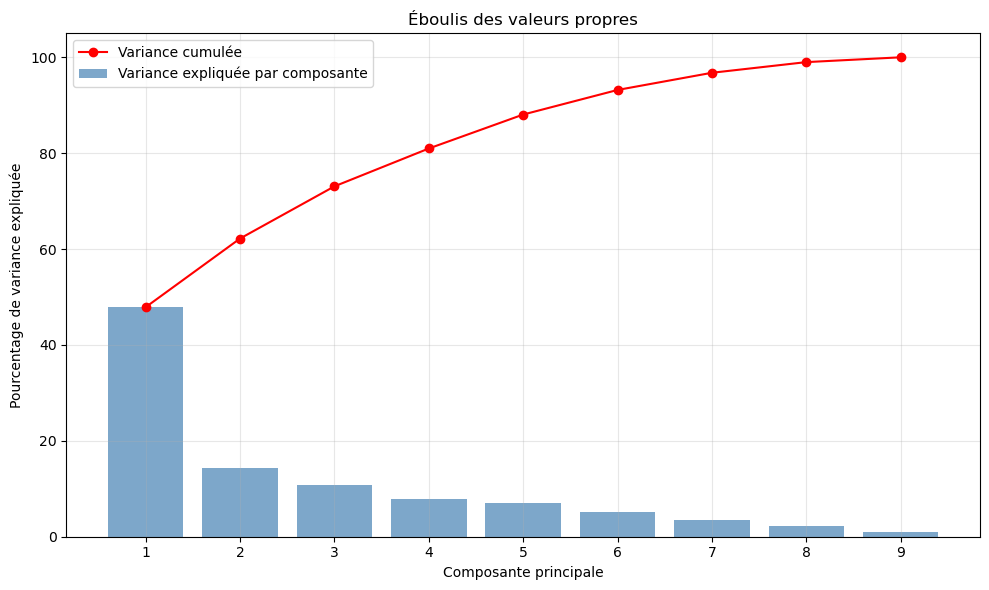

In [10]:
# On récupère le nombre de composantes pour l'axe horizontal
n_composantes = len(variance_expliquee)

# On crée une liste [1, 2, ..., 9] pour numéroter les composantes
numeros = range(1, n_composantes + 1)

# On crée la figure
plt.figure(figsize=(10, 6))

# Barres : le % de variance expliquée par CHAQUE composante individuellement
plt.bar(numeros, variance_expliquee, alpha=0.7, color='steelblue',
        label="Variance expliquée par composante")

# Courbe : la variance CUMULÉE (on additionne au fur et à mesure)
# np.cumsum fait la somme cumulée : [42, 42+15, 42+15+10, ...]
plt.plot(numeros, np.cumsum(variance_expliquee), color='red', marker='o',
         label="Variance cumulée")

# Titres des axes et du graphique
plt.xlabel("Composante principale")
plt.ylabel("Pourcentage de variance expliquée")
plt.title("Éboulis des valeurs propres")

# On force l'axe X à afficher 1, 2, 3... (nombres entiers)
plt.xticks(numeros)

# Affiche la légende (les étiquettes label définies plus haut)
plt.legend()

# Une grille légère pour faciliter la lecture
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Choix du nombre de dimensions

L'éboulis des valeurs propres montre :

- **PC1** capture 47,9 % de la variance, **PC2** 14,3 % et **PC3** 10,9 %.
- La variance cumulée atteint **62 % avec 2 axes** et **73 % avec 3 axes**.

Trois critères ont été considérés :
- **Critère du coude** : la décroissance des barres ralentit nettement après la 3e composante.
- **Variance cumulée** : 3 axes suffisent à conserver près des trois quarts de l'information (73 %).
- **Critère de Kaiser** : PC1 et PC2 dépassent le seuil, PC3 est juste en dessous.

**Décision : je retiens 3 composantes principales** pour l'analyse, afin de conserver un bon niveau 
d'information (73 %) sans surcharger le modèle. Les visualisations (cercle des corrélations, 
projection des individus) sont réalisées sur le plan principal PC1-PC2, qui résume déjà 62 % de 
l'information.

<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="cercle"><h2 style="margin: auto; padding: 20px; color:#fff;">3.3 Cercle des corrélations</h2></a>
</div>


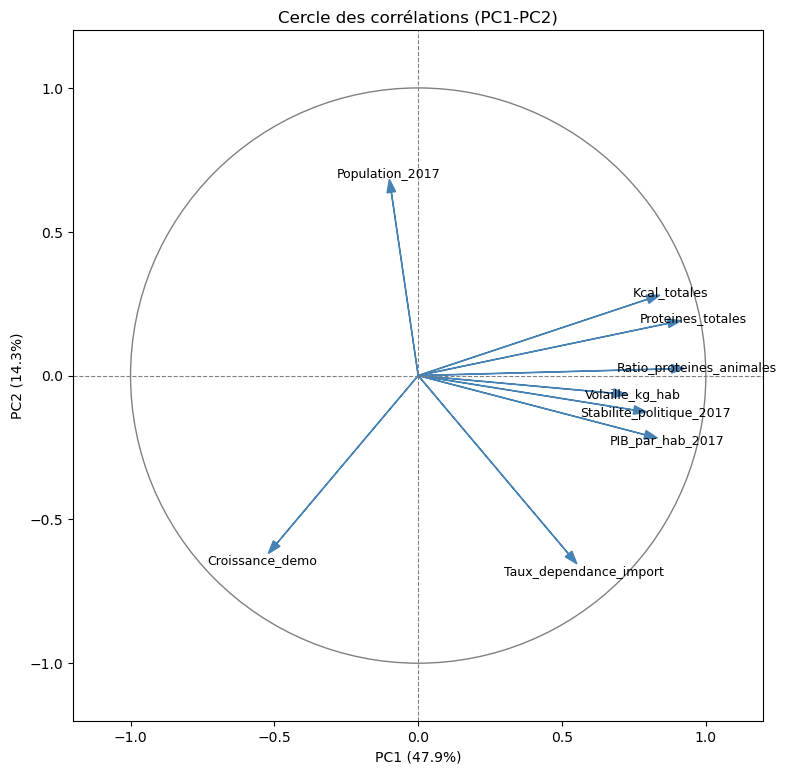

In [ ]:
# On calcule les coordonnées des variables sur les axes
# pca.components_ contient les directions des axes ; on les multiplie par la racine
# des valeurs propres (np.sqrt(pca.explained_variance_)) pour obtenir les corrélations
# entre chaque variable d'origine et chaque composante principale
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# On choisit les deux axes à afficher : PC1 (indice 0) en x, PC2 (indice 1) en y
x_axe = 0  # PC1
y_axe = 1  # PC2

# On crée une figure carrée
fig, ax = plt.subplots(figsize=(8, 8))

# On parcourt chaque variable pour dessiner sa flèche
for i, var in enumerate(vars_analyse):
    # On trace une flèche du centre (0,0) vers les coordonnées de la variable
    ax.arrow(0, 0,                       # point de départ : le centre
             loadings[i, x_axe],         # coordonnée x (sur PC1)
             loadings[i, y_axe],         # coordonnée y (sur PC2)
             head_width=0.03,            # taille de la pointe de flèche
             color='steelblue')
    # On écrit le nom de la variable au bout de la flèche
    # Le *1.1 décale légèrement le texte pour qu'il ne chevauche pas la flèche
    ax.text(loadings[i, x_axe]*1.1, loadings[i, y_axe]*1.1,
            var, color='black', ha='center', va='center', fontsize=9)

# On dessine le cercle de rayon 1 (le "cercle de corrélation")
cercle = plt.Circle((0, 0), 1, color='grey', fill=False)
ax.add_artist(cercle)

# On trace les axes horizontal et vertical passant par 0, en pointillés gris
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)

# On fixe les limites du graphique un peu au-delà du cercle pour tout voir
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

# On étiquette les axes avec le % de variance de chaque composante
ax.set_xlabel(f"PC1 ({variance_expliquee[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({variance_expliquee[1]:.1f}%)")

# Titre du graphique
ax.set_title("Cercle des corrélations (PC1-PC2)")

# set_aspect('equal') garantit que le cercle reste rond et non ovale
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Interprétation du cercle des corrélations

Toutes les variables sont bien représentées (flèches longues, proches du cercle), 
on peut donc les interpréter avec confiance.

**Axe PC1 (47,9 %) — niveau de développement.**
Six variables pointent dans la même direction (droite) et sont donc fortement corrélées entre 
elles : ratio de protéines animales, protéines totales, calories, PIB par habitant, consommation 
de volaille et stabilité politique. À l'opposé, la croissance démographique pointe vers la gauche : 
elle est corrélée négativement à ce bloc. Un pays à droite est riche, stable et bien nourri en 
protéines animales ; un pays à gauche connaît une forte croissance démographique.

**Axe PC2 (14,3 %) — taille du pays vs dépendance aux importations.**
La population domine le haut de l'axe, opposée au taux de dépendance aux importations et à la 
croissance démographique (vers le bas). PC2 distingue les grands pays peuplés des petits territoires 
dépendants des importations.

**Observation clé :** la flèche de la population est quasi perpendiculaire au bloc de développement. 
Population et richesse sont donc non corrélées : la taille d'un pays est indépendante de son niveau 
de développement. Ce résultat est cohérent avec la matrice de corrélation.

<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="projection"><h2 style="margin: auto; padding: 20px; color:#fff;">3.4 Projection des individus</h2></a>
</div>


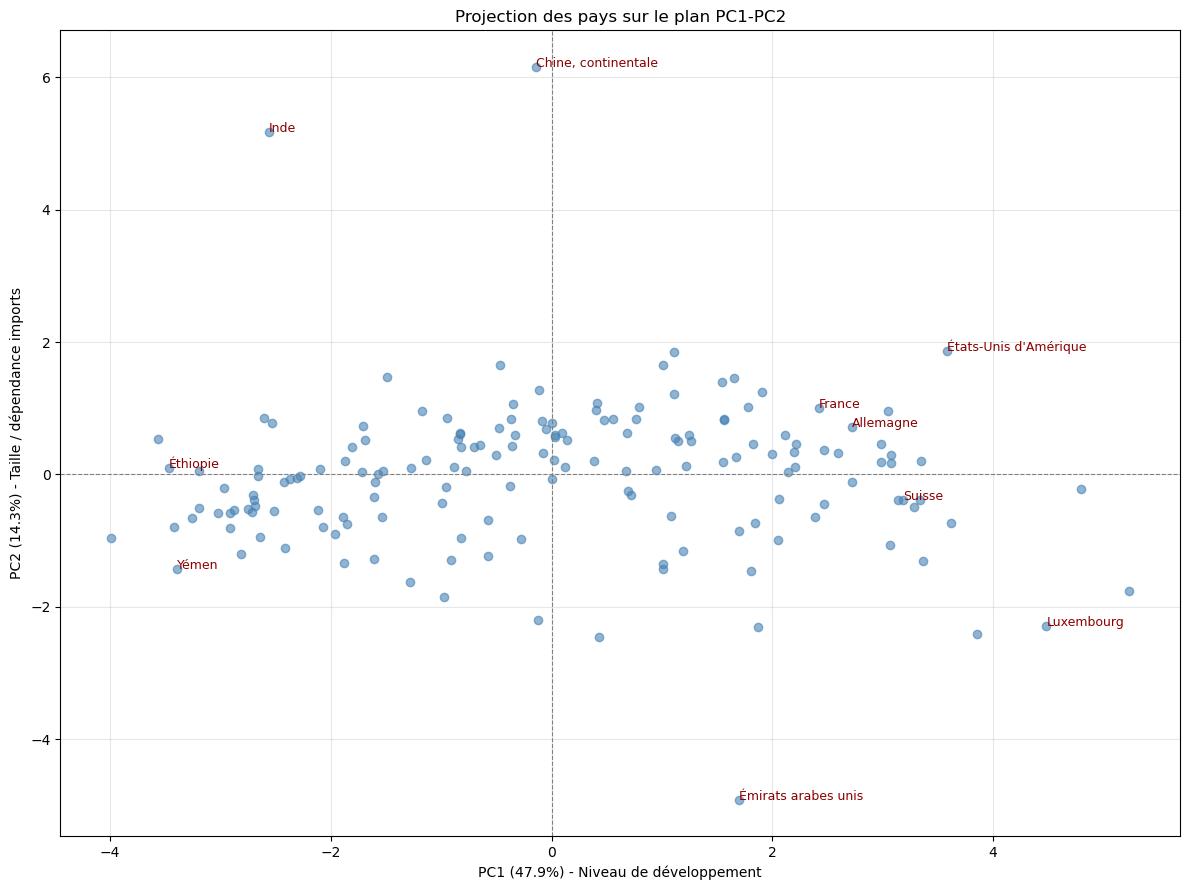

In [12]:
# X_pca contient déjà les coordonnées des 165 pays sur les composantes
# (calculé à l'étape de l'ACP avec pca.fit_transform). 
# X_pca[:, 0] = coordonnées sur PC1 (1re colonne), X_pca[:, 1] = coordonnées sur PC2

# On crée la figure
plt.figure(figsize=(12, 9))

# On dessine un nuage de points : chaque pays est un point (x=PC1, y=PC2)
# alpha=0.6 rend les points semi-transparents pour mieux voir les superpositions
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color='steelblue')

# On trace les axes horizontal et vertical passant par 0 (le centre du nuage)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

# On choisit quelques pays repères à étiqueter pour ne pas surcharger le graphique
pays_reperes = ['Chine, continentale', 'Inde', "États-Unis d'Amérique",
                'Luxembourg', 'Suisse', 'Yémen', 'Émirats arabes unis',
                'Éthiopie', 'France', 'Allemagne']

# On parcourt chaque pays repère pour écrire son nom au bon endroit
for pays in pays_reperes:
    # On récupère la position (l'index) du pays dans le DataFrame
    # df[df['Zone'] == pays].index[0] trouve la ligne où Zone est ce pays
    idx = df[df['Zone'] == pays].index[0]
    # On écrit le nom du pays à ses coordonnées PC1/PC2
    plt.text(X_pca[idx, 0], X_pca[idx, 1], pays, fontsize=9, color='darkred')

# On étiquette les axes avec le pourcentage de variance de chaque composante
plt.xlabel(f"PC1 ({variance_expliquee[0]:.1f}%) - Niveau de développement")
plt.ylabel(f"PC2 ({variance_expliquee[1]:.1f}%) - Taille / dépendance imports")

# Titre du graphique
plt.title("Projection des pays sur le plan PC1-PC2")

# Grille légère pour faciliter la lecture
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Interprétation de la projection des individus

Les 165 pays sont projetés sur le plan PC1-PC2 :

- **À droite (PC1 élevé)** : les pays développés (Luxembourg, Suisse, États-Unis, Allemagne, 
France), riches, stables et gros consommateurs de protéines animales.
- **À gauche (PC1 faible)** : les pays moins développés à forte croissance démographique 
(Éthiopie, Yémen).
- **En haut (PC2 élevé)** : les géants démographiques (Chine, Inde), nettement détachés.
- **En bas (PC2 faible)** : les pays très dépendants des importations (Émirats arabes unis).

La majorité des pays forment une masse compacte au centre, avec quelques cas extrêmes isolés. 
Le nuage présente un gradient de développement plutôt que des groupes nettement séparés : 
le nombre de clusters devra donc être déterminé par des méthodes dédiées (dendrogramme, 
méthode du coude) plutôt qu'à l'œil.

<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="clustering"><h2 style="margin: auto; padding: 20px; color:#fff;">4. Clustering</h2></a>
</div>


<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="cah"><h2 style="margin: auto; padding: 20px; color:#fff;">4.1 CAH et dendrogramme</h2></a>
</div>


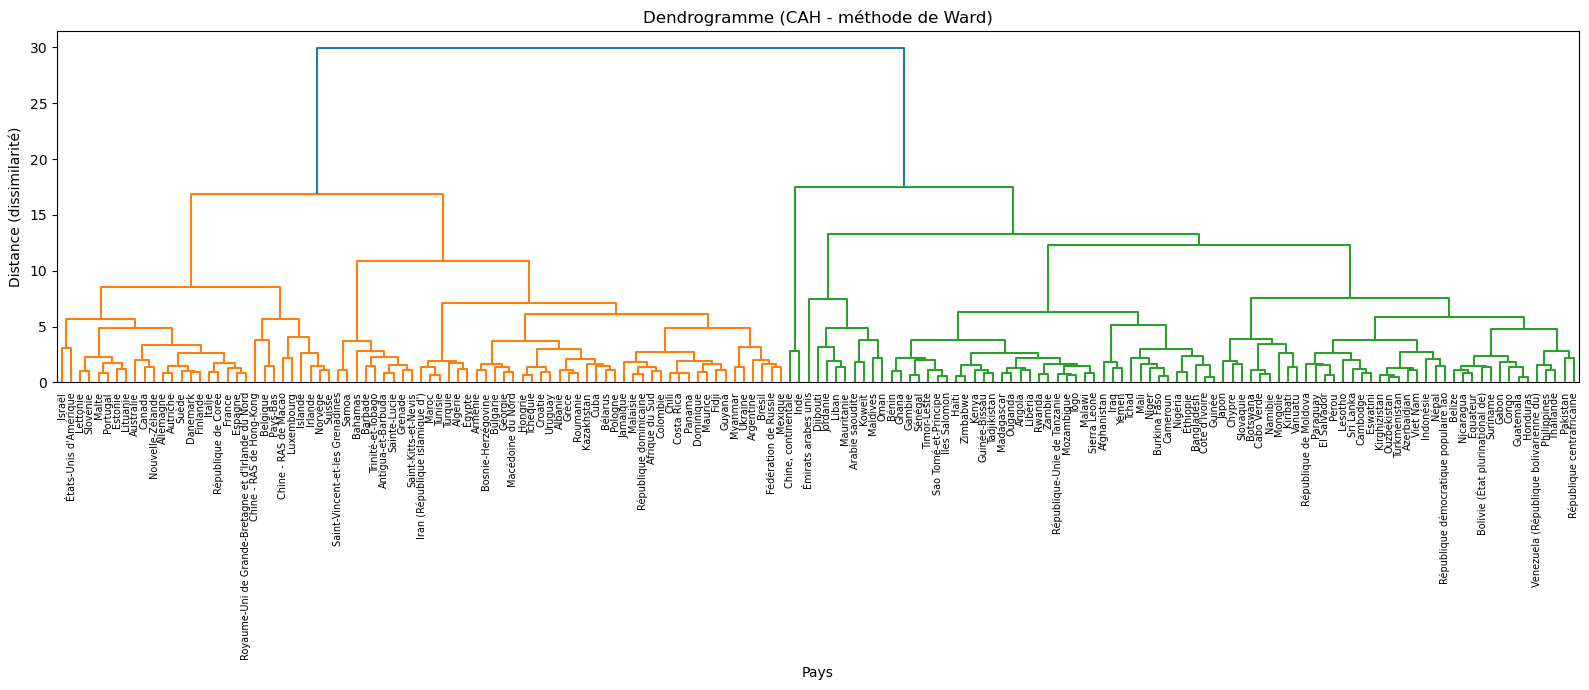

In [ ]:
# On importe les outils pour la CAH depuis scipy
# linkage : calcule les fusions successives ; dendrogram : dessine l'arbre
from scipy.cluster.hierarchy import linkage, dendrogram

# On calcule la matrice de liaison (l'ordre des fusions) sur les données standardisées
# method='ward' : méthode de Ward, qui forme des groupes compacts et homogènes
# (Ward utilise implicitement la distance euclidienne, c'est le choix standard)
matrice_liaison = linkage(X_scaled, method='ward')

# On crée une figure large pour bien voir toutes les branches
plt.figure(figsize=(16, 7))

# On dessine le dendrogramme à partir de la matrice de liaison
dendrogram(
    matrice_liaison,           # les fusions calculées juste avant
    labels=df['Zone'].values,  # on met le nom des pays en bas de l'arbre
    leaf_rotation=90,          # on tourne les noms à 90° pour qu'ils soient lisibles
    leaf_font_size=7           # taille de police des noms de pays
)

# Titres
plt.title("Dendrogramme (CAH - méthode de Ward)")
plt.xlabel("Pays")
plt.ylabel("Distance (dissimilarité)")

plt.tight_layout()
plt.show()

## CAH — Interprétation du dendrogramme

Le dendrogramme (méthode de Ward, données standardisées) fait apparaître deux grandes familles 
de pays à la coupe la plus haute :
- un bloc de **pays développés** (États-Unis, Allemagne, France, Suisse, Luxembourg, pays nordiques, 
Japon...) ;
- un bloc de **pays en développement** (Éthiopie, Niger, Mali, Bangladesh, Bolivie...).

En coupant plus bas, ces blocs se subdivisent, ce qui suggère un découpage en 3 à 4 clusters. 
L'analyse des hauteurs de fusion confirme ce résultat (plus grand saut de distance au passage de 
4 à 3 clusters). Le nombre optimal sera confirmé par la méthode du coude appliquée au KMeans.

<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="kmeans"><h2 style="margin: auto; padding: 20px; color:#fff;">4.2 KMeans et méthode du coude</h2></a>
</div>


## Calcul de l'inertie de chaque k

In [14]:
# On importe l'outil KMeans depuis scikit-learn
from sklearn.cluster import KMeans

# On va tester plusieurs nombres de clusters, de 1 à 10
# range(1, 11) génère les nombres 1, 2, 3, ..., 10
valeurs_k = range(1, 11)

# On prépare une liste vide pour stocker l'inertie de chaque k
inerties = []

# Pour chaque nombre de clusters k, on entraîne un KMeans et on récupère son inertie
for k in valeurs_k:
    # On crée un KMeans avec k clusters
    # random_state=42 fixe le hasard pour avoir un résultat reproductible à chaque exécution
    # n_init=10 : KMeans est lancé 10 fois avec des départs différents, il garde le meilleur
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # On l'entraîne sur les données standardisées
    kmeans.fit(X_scaled)

    # .inertia_ contient l'inertie calculée ; on l'ajoute à notre liste
    inerties.append(kmeans.inertia_)

# On affiche les inerties obtenues pour chaque k
for k, inertie in zip(valeurs_k, inerties):
    print(f"k = {k} : inertie = {inertie:.1f}")

c:\Users\oubak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\oubak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\oubak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\oubak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

k = 1 : inertie = 1485.0
k = 2 : inertie = 974.4
k = 3 : inertie = 823.6
k = 4 : inertie = 677.9
k = 5 : inertie = 611.2
k = 6 : inertie = 543.7
k = 7 : inertie = 495.8
k = 8 : inertie = 458.7
k = 9 : inertie = 442.0
k = 10 : inertie = 405.5


c:\Users\oubak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\oubak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Traçage de courbe

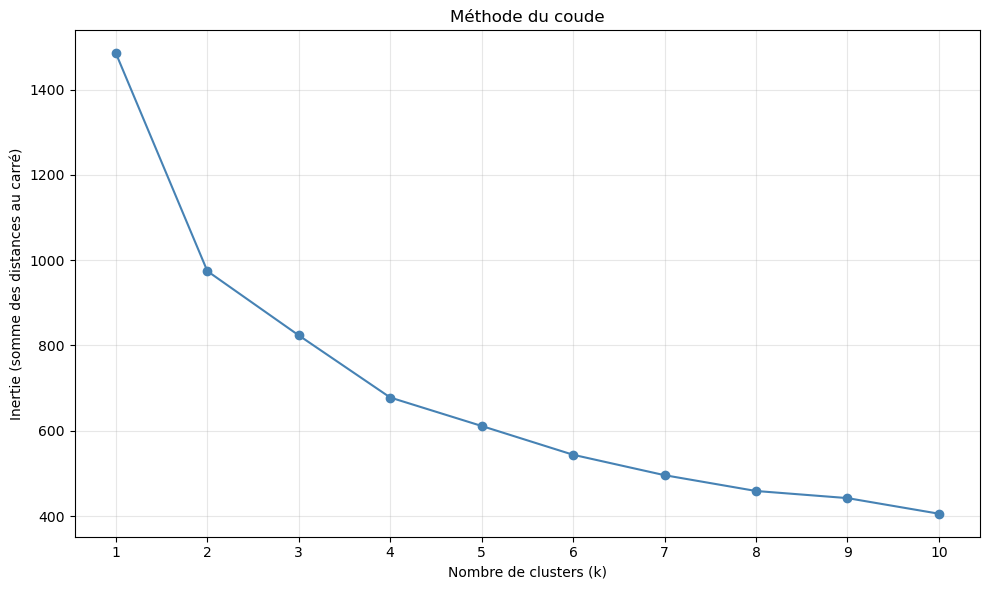

In [15]:
# On crée la figure
plt.figure(figsize=(10, 6))

# On trace l'inertie en fonction du nombre de clusters
# marker='o' met un point sur chaque valeur, pour bien voir le coude
plt.plot(valeurs_k, inerties, marker='o', color='steelblue')

# Titres des axes
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie (somme des distances au carré)")
plt.title("Méthode du coude")

# On force l'axe x à afficher tous les entiers 1 à 10
plt.xticks(valeurs_k)

# Grille légère
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# On calcule la baisse d'inertie entre chaque k et le suivant
# Cela aide à repérer le "coude" : tant que la baisse est forte, ajouter un cluster est utile
for i in range(1, len(inerties)):
    # inerties[i-1] = inertie du k précédent, inerties[i] = inertie du k actuel
    baisse = inerties[i-1] - inerties[i]
    # i vaut la position dans la liste ; comme k commence à 1, on passe de k=i à k=i+1
    print(f"De k={i} à k={i+1} : baisse d'inertie = {baisse:.1f}")

De k=1 à k=2 : baisse d'inertie = 510.6
De k=2 à k=3 : baisse d'inertie = 150.7
De k=3 à k=4 : baisse d'inertie = 145.7
De k=4 à k=5 : baisse d'inertie = 66.7
De k=5 à k=6 : baisse d'inertie = 67.5
De k=6 à k=7 : baisse d'inertie = 47.9
De k=7 à k=8 : baisse d'inertie = 37.1
De k=8 à k=9 : baisse d'inertie = 16.7
De k=9 à k=10 : baisse d'inertie = 36.6


<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="application"><h2 style="margin: auto; padding: 20px; color:#fff;">4.3 Application du KMeans (k=4)</h2></a>
</div>


## Application du K-means et récupération des clusters

In [17]:
# On crée le modèle KMeans avec 4 clusters (le choix qu'on a retenu)
# random_state=42 : résultat reproductible ; n_init=10 : 10 essais, on garde le meilleur
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

# .fit_predict() fait deux choses : il entraîne le modèle ET renvoie le numéro
# de cluster (0, 1, 2 ou 3) de chaque pays, dans l'ordre des lignes de X_scaled
clusters = kmeans_final.fit_predict(X_scaled)

# On ajoute ces numéros de cluster comme une nouvelle colonne dans df
# Comme X_scaled a été construit dans le même ordre que df, les lignes correspondent
df['Cluster'] = clusters

# On vérifie combien de pays il y a dans chaque cluster
# value_counts() compte les occurrences de chaque numéro
print("Nombre de pays par cluster :")
print(df['Cluster'].value_counts().sort_index())

Nombre de pays par cluster :
Cluster
0    63
1    43
2    57
3     2
Name: count, dtype: int64


c:\Users\oubak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Visualisation en couleur sur la projection ACP

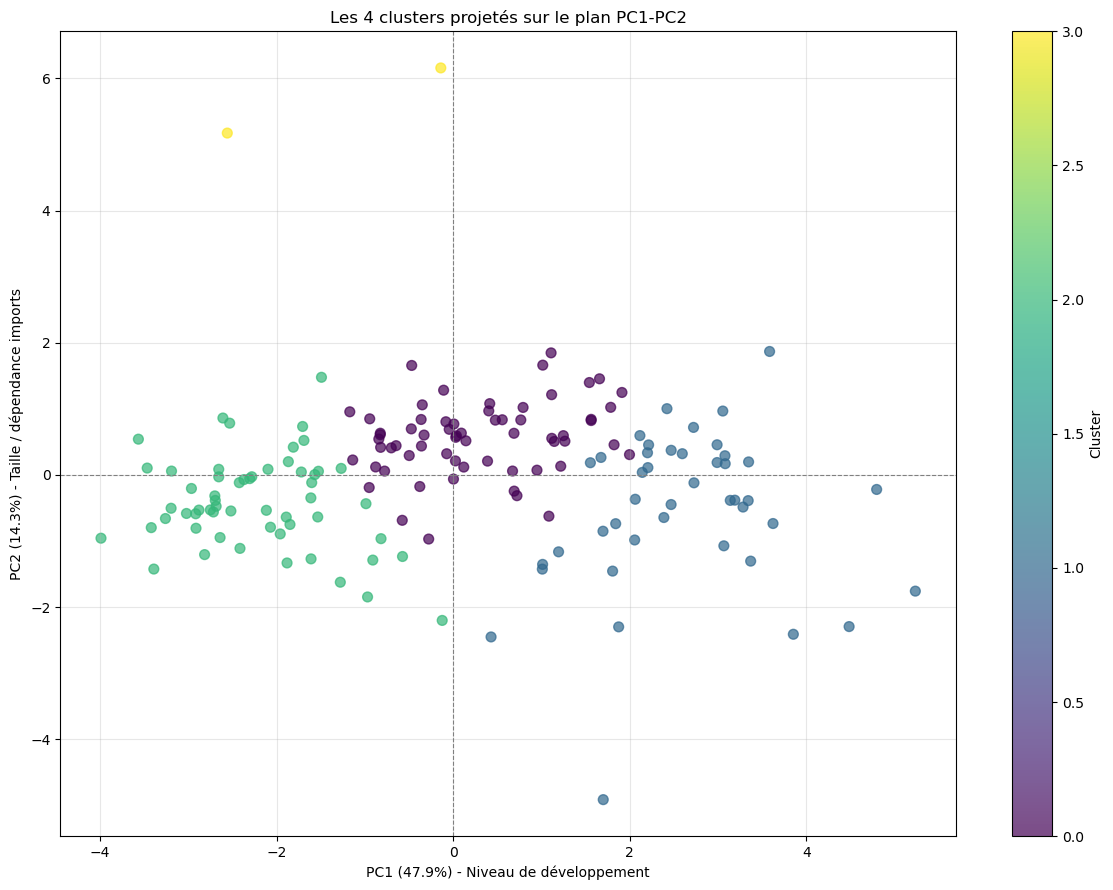

In [18]:
# On crée la figure
plt.figure(figsize=(12, 9))

# On dessine le nuage de points en coloriant selon le cluster
# c=df['Cluster'] : la couleur de chaque point dépend de son numéro de cluster
# cmap='viridis' : la palette de couleurs utilisée
# On récupère l'objet "scatter" dans une variable pour pouvoir ajouter la légende
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['Cluster'], cmap='viridis', alpha=0.7, s=50)

# On trace les axes passant par 0
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

# On ajoute une barre de couleur qui indique quel numéro correspond à quelle couleur
plt.colorbar(scatter, label='Cluster')

# Étiquettes des axes avec le % de variance
plt.xlabel(f"PC1 ({variance_expliquee[0]:.1f}%) - Niveau de développement")
plt.ylabel(f"PC2 ({variance_expliquee[1]:.1f}%) - Taille / dépendance imports")

# Titre
plt.title("Les 4 clusters projetés sur le plan PC1-PC2")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## KMeans — Interprétation des 4 clusters

Le KMeans (k=4, données standardisées) forme quatre groupes :

- **Cluster 1 — pays développés (43 pays)** : PIB élevé (~40 000 $), forte consommation de volaille, 
stabilité positive (Allemagne, Australie, Belgique...).
- **Cluster 0 — pays intermédiaires (63 pays)** : revenu moyen (~7 500 $), consommation modérée 
(Afrique du Sud, Argentine, Algérie...).
- **Cluster 2 — pays en développement (57 pays)** : PIB faible (~2 150 $), forte croissance 
démographique, faible consommation de volaille (Bangladesh, Burkina Faso, Cameroun...).
- **Cluster 3 — géants démographiques (2 pays)** : Chine et Inde, isolés par leur population 
supérieure au milliard d'habitants.

Le cluster 3, réduit à deux pays, reflète le caractère très atypique de la Chine et de l'Inde. 
Ce segment est conservé car ces deux pays constituent des marchés d'une échelle unique.

<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="comparaison"><h2 style="margin: auto; padding: 20px; color:#fff;">4.4 Comparaison CAH et KMeans</h2></a>
</div>


## Extraction des 4 clusters de la CAH

In [19]:
# On importe fcluster : il "coupe" le dendrogramme pour obtenir un nombre voulu de clusters
from scipy.cluster.hierarchy import fcluster

# On coupe l'arbre (matrice_liaison, calculée à l'étape CAH) pour obtenir 4 clusters
# criterion='maxclust' : on demande AU PLUS 4 clusters
clusters_cah = fcluster(matrice_liaison, t=4, criterion='maxclust')

# On ajoute ces clusters CAH comme nouvelle colonne dans df
df['Cluster_CAH'] = clusters_cah

# On regarde combien de pays par cluster CAH
print("Nombre de pays par cluster (CAH) :")
print(df['Cluster_CAH'].value_counts().sort_index())

Nombre de pays par cluster (CAH) :
Cluster_CAH
1    30
2    49
3     2
4    84
Name: count, dtype: int64


## Comparaison CAH et Kmeans

In [20]:
# pd.crosstab croise les deux colonnes : il compte combien de pays sont dans
# chaque combinaison (cluster KMeans, cluster CAH)
comparaison = pd.crosstab(df['Cluster'], df['Cluster_CAH'],
                          rownames=['KMeans'], colnames=['CAH'])

# On affiche le tableau
print("Tableau croisé KMeans vs CAH :")
print(comparaison)

Tableau croisé KMeans vs CAH :
CAH      1   2  3   4
KMeans               
0        0  42  0  21
1       30   7  0   6
2        0   0  0  57
3        0   0  2   0


## Comparaison CAH vs KMeans

Le tableau croisé des deux méthodes montre une forte concordance sur la structure globale :
- Chine et Inde sont isolées à l'identique par les deux méthodes (segment des géants).
- Les 57 pays en développement du KMeans se retrouvent entièrement dans un même cluster CAH.
- Le noyau des pays développés (30 pays) est classé de façon identique.

Les différences concernent surtout les pays intermédiaires, à la frontière entre deux groupes, 
que chaque méthode répartit selon sa logique propre :
- le **KMeans** affecte chaque pays au centre le plus proche (groupes sphériques, sensible à 
l'initialisation) ;
- la **CAH** fusionne progressivement par proximité (déterministe, structure hiérarchique).

La concordance sur les cas nets valide la robustesse de la segmentation ; les écarts sur les cas 
ambigus sont attendus.

<div style="background-color: RGB(0,150,250);">
<a class="anchor" id="recommandations"><h2 style="margin: auto; padding: 20px; color:#fff;">4.5 Recommandations pour l'entreprise</h2></a>
</div>


## Profil de chaque cluster

In [21]:
# On calcule la moyenne de chaque variable pour chaque cluster KMeans
# groupby('Cluster') regroupe les pays par cluster, .mean() fait la moyenne de chaque variable
profil_clusters = df.groupby('Cluster')[vars_analyse].mean()

# On affiche le profil, arrondi à 1 décimale pour la lisibilité
print("Profil moyen de chaque cluster :")
print(profil_clusters.round(1).to_string())

# On ajoute le nombre de pays par cluster pour avoir le contexte
print("\nNombre de pays par cluster :")
print(df['Cluster'].value_counts().sort_index())

Profil moyen de chaque cluster :
         Population_2017  Croissance_demo  Proteines_totales  Kcal_totales  Volaille_kg_hab  Taux_dependance_import  Ratio_proteines_animales  PIB_par_hab_2017  Stabilite_politique_2017
Cluster                                                                                                                                                                                  
0                25795.8             15.4               84.5        2995.4             23.7                     0.2                       0.5            7560.4                      -0.0
1                24631.8             22.6              102.1        3236.6             33.3                     0.6                       0.6           40315.5                       0.7
2                32014.9             51.2               61.4        2432.7              6.9                     0.2                       0.3            2157.7                      -0.7
3              1379849.3             

## Visualisation des critères clès

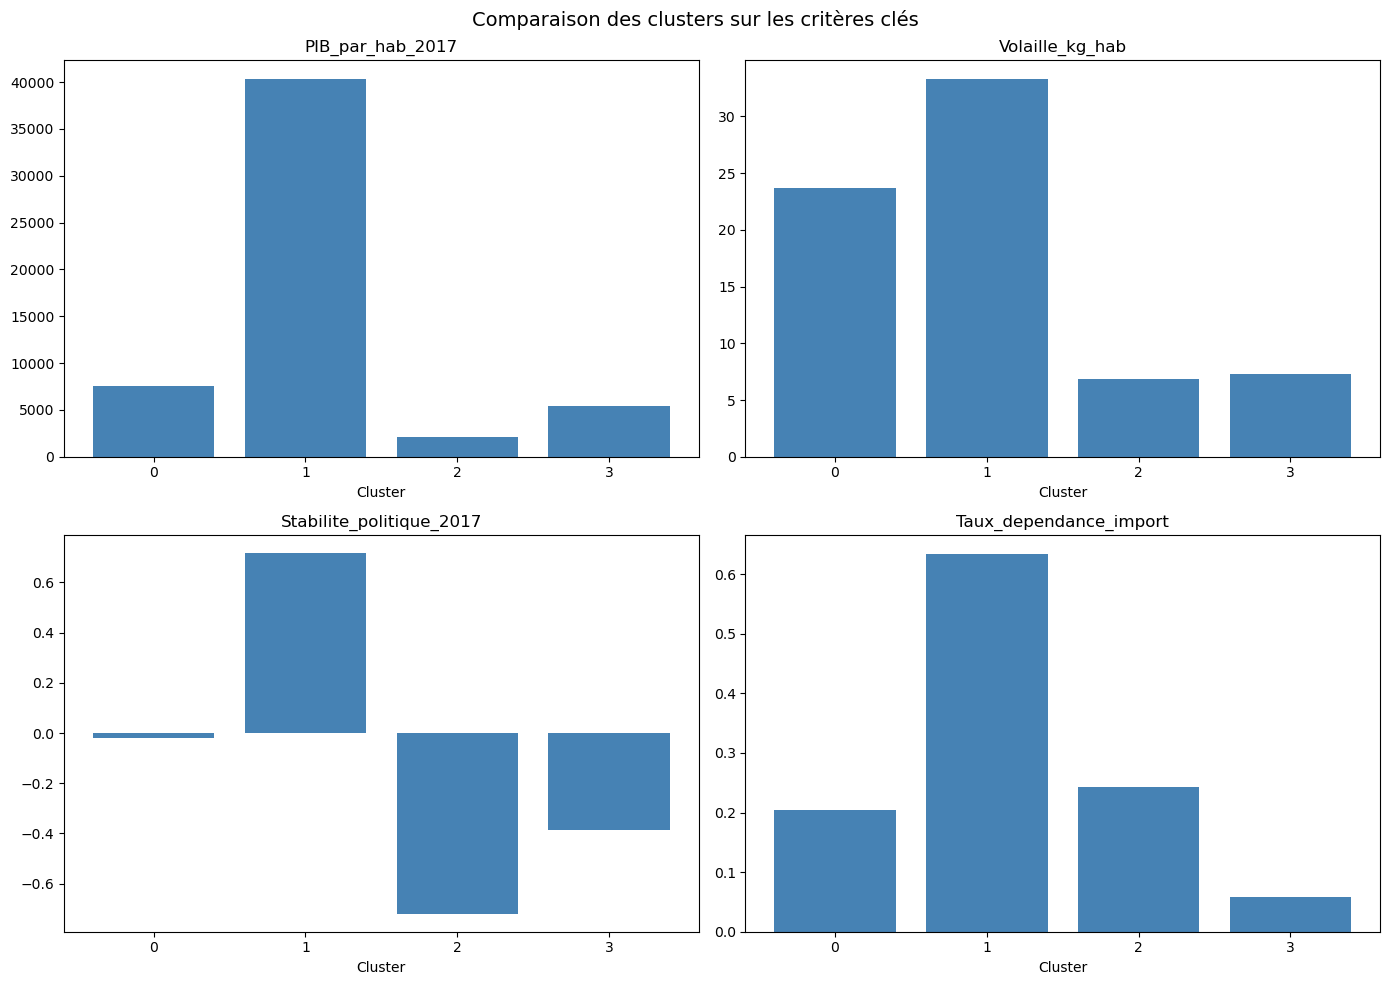

In [22]:
# On choisit les 4 critères les plus parlants pour l'entreprise
criteres_cles = ['PIB_par_hab_2017', 'Volaille_kg_hab',
                 'Stabilite_politique_2017', 'Taux_dependance_import']

# On crée une grille de 2x2 graphiques (un par critère)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Pour chaque critère, on dessine un diagramme en barres de la moyenne par cluster
for i, critere in enumerate(criteres_cles):
    # profil_clusters[critere] contient la moyenne de ce critère pour chaque cluster
    axes[i].bar(profil_clusters.index, profil_clusters[critere], color='steelblue')
    axes[i].set_title(critere)              # titre = nom du critère
    axes[i].set_xlabel("Cluster")           # axe x = numéro de cluster
    axes[i].set_xticks(profil_clusters.index)  # affiche 0,1,2,3

plt.suptitle("Comparaison des clusters sur les critères clés", fontsize=14)
plt.tight_layout()
plt.show()

## Recommandations pour l'entreprise

**Cluster cible : le cluster des pays développés (cluster 1).**

Ce groupe cumule les quatre atouts recherchés pour exporter un poulet bio premium :
- pouvoir d'achat le plus élevé (PIB moyen ~40 000 $, soit 5 fois celui des pays intermédiaires) ;
- consommation de volaille la plus forte (33 kg/hab/an) : marché déjà friand ;
- meilleure stabilité politique (+0,7) : risque commercial réduit ;
- forte ouverture aux importations (taux 0,6) : marché accessible.

Les autres clusters sont moins adaptés : les pays en développement (cluster 2) manquent de pouvoir 
d'achat pour un produit premium ; les pays intermédiaires (cluster 0) sont moyens sur tous les 
critères ; les géants Chine/Inde (cluster 3) ont une faible consommation de volaille et une 
stabilité négative.

**Pays prioritaires au sein du cluster cible :** États-Unis, Australie, Canada, Nouvelle-Zélande, 
Israël, ainsi que des marchés européens proches (Royaume-Uni, Espagne, Portugal) intéressants sur 
le plan logistique. L'Arabie saoudite, bien que grande consommatrice, est à considérer avec prudence 
en raison d'une stabilité politique plus faible.

Cette recommandation découle directement de l'analyse : ACP pour comprendre la structure des 
données, puis clustering (CAH et KMeans convergents) pour segmenter les 165 pays.